<a href="https://colab.research.google.com/github/joshuashaji30-star/Ict_DSA_works/blob/main/Supervised_casestudy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#SUPERVISED_LEARNING CASESTUDY

###Libraries



In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler,StandardScaler,LabelEncoder, OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn import svm
from sklearn import tree

from sklearn.metrics import confusion_matrix, precision_score, recall_score,f1_score
from sklearn.metrics import accuracy_score

from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

In [3]:
### Training data file_path
file_path1=('/content/drive/MyDrive/DSA_class/DSA datasets/Training_data.csv')

### Testing data file_path
file_path2=('/content/drive/MyDrive/DSA_class/DSA datasets/Testing_data.csv')



##Exploratory Data Analysis-EDA

In [4]:
##LOading Training Data
train_df=pd.read_csv(file_path1)
train_df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,9509-MPYOD,Female,0,No,No,35,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.75,700.45,No
1,7746-AWNQW,Female,0,No,No,28,No,No phone service,DSL,No,...,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,35.75,961.4,No
2,2208-UGTGR,Male,0,No,No,56,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,No,Electronic check,98.60,5581.05,No
3,4884-LEVMQ,Male,0,Yes,No,39,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),20.45,790,No
4,6682-VCIXC,Female,0,Yes,Yes,43,No,No phone service,DSL,NaN,...,No,Yes,Yes,No,One year,Yes,Bank transfer (automatic),51.25,2151.6,No


In [5]:
##Loading Test data
test_df=pd.read_csv(file_path2)
test_df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,6080-TCMYC,Male,0,Yes,Yes,40,Yes,Yes,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,81.20,3292.3,No
1,7285-KLOTR,Female,0,Yes,No,12,Yes,Yes,DSL,Yes,...,Yes,No,Yes,Yes,One year,No,Electronic check,78.85,876.75,No
2,7486-KSRVI,Male,0,No,No,43,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,Yes,One year,Yes,Electronic check,100.00,4211.55,Yes
3,9924-JPRMC,Male,0,No,No,72,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,118.20,8547.15,No
4,4439-YRNVD,Female,0,No,No,10,No,No phone service,DSL,No,...,No,Yes,No,No,Month-to-month,No,Electronic check,36.25,374,No


In [6]:
##Info train data
train_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5634 entries, 0 to 5633
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        5634 non-null   object 
 1   gender            5465 non-null   object 
 2   SeniorCitizen     5634 non-null   int64  
 3   Partner           5634 non-null   object 
 4   Dependents        5634 non-null   object 
 5   tenure            5634 non-null   int64  
 6   PhoneService      5634 non-null   object 
 7   MultipleLines     5634 non-null   object 
 8   InternetService   5634 non-null   object 
 9   OnlineSecurity    5465 non-null   object 
 10  OnlineBackup      5634 non-null   object 
 11  DeviceProtection  5634 non-null   object 
 12  TechSupport       5634 non-null   object 
 13  StreamingTV       5634 non-null   object 
 14  StreamingMovies   5634 non-null   object 
 15  Contract          5634 non-null   object 
 16  PaperlessBilling  5634 non-null   object 


In [7]:
## Info test data
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1409 entries, 0 to 1408
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        1409 non-null   object 
 1   gender            1409 non-null   object 
 2   SeniorCitizen     1409 non-null   int64  
 3   Partner           1409 non-null   object 
 4   Dependents        1409 non-null   object 
 5   tenure            1409 non-null   int64  
 6   PhoneService      1409 non-null   object 
 7   MultipleLines     1409 non-null   object 
 8   InternetService   1409 non-null   object 
 9   OnlineSecurity    1409 non-null   object 
 10  OnlineBackup      1409 non-null   object 
 11  DeviceProtection  1409 non-null   object 
 12  TechSupport       1409 non-null   object 
 13  StreamingTV       1409 non-null   object 
 14  StreamingMovies   1409 non-null   object 
 15  Contract          1409 non-null   object 
 16  PaperlessBilling  1409 non-null   object 


In [8]:
##Statistical Analysis of train data
train_df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,5634.000000,5634.000000,5240.000000
mean,0.159744,32.606851,65.102052
std,0.366401,24.614976,30.056443
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,36.800000
50%,0.000000,29.000000,70.650000
75%,0.000000,56.000000,90.050000
max,1.000000,72.000000,118.750000


In [9]:
## Testing data Statistical analysis
test_df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,1409.000000,1409.000000,1409.000000
mean,0.171753,31.428673,63.898013
std,0.377300,24.322161,30.282693
min,0.000000,0.000000,18.700000
25%,0.000000,8.000000,30.100000
50%,0.000000,27.000000,69.900000
75%,0.000000,54.000000,89.500000
max,1.000000,72.000000,118.600000


In [10]:
## Checking is ther any missing values in training data
train_df.isna().sum()

,0
customerID,0
gender,169
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,169


In [11]:
##Checking for missing values in Testing data
test_df.isna().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [12]:
train_df.duplicated().sum() ##checking for duplicate values in training data

np.int64(0)

In [13]:
test_df.duplicated().sum() ##Checking for duplicates in testing data

np.int64(0)

In [14]:
## coverting object into numeric
train_df['TotalCharges'] = pd.to_numeric(train_df['TotalCharges'], errors='coerce')

In [15]:
## coverting totalcharges to numeric
test_df['TotalCharges']= pd.to_numeric(test_df['TotalCharges'],errors='coerce')

In [16]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5634 entries, 0 to 5633
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        5634 non-null   object 
 1   gender            5465 non-null   object 
 2   SeniorCitizen     5634 non-null   int64  
 3   Partner           5634 non-null   object 
 4   Dependents        5634 non-null   object 
 5   tenure            5634 non-null   int64  
 6   PhoneService      5634 non-null   object 
 7   MultipleLines     5634 non-null   object 
 8   InternetService   5634 non-null   object 
 9   OnlineSecurity    5465 non-null   object 
 10  OnlineBackup      5634 non-null   object 
 11  DeviceProtection  5634 non-null   object 
 12  TechSupport       5634 non-null   object 
 13  StreamingTV       5634 non-null   object 
 14  StreamingMovies   5634 non-null   object 
 15  Contract          5634 non-null   object 
 16  PaperlessBilling  5634 non-null   object 


##Data Preprocessing

In [17]:
##Dividing Cat and Num colums

train_df_num_cols=train_df.select_dtypes(include=['int64','float64']).columns
train_df_cat_cols=train_df.select_dtypes(include=['object']).columns

In [18]:
train_df_cat_cols

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')

In [19]:
train_df_num_cols

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')

In [20]:
missing_percent_train=train_df.isna().sum()/len(train_df)*100  ## Checking the of missing values
sorted=missing_percent_train.sort_values(ascending=True)

In [21]:
sorted

,0
customerID,0.000000
SeniorCitizen,0.000000
Partner,0.000000
Dependents,0.000000
PhoneService,0.000000
tenure,0.000000
MultipleLines,0.000000
InternetService,0.000000
StreamingMovies,0.000000
OnlineBackup,0.000000


In [22]:
## dividing categorical col and numerical col
test_df_num_cols=test_df.select_dtypes(include=['int64','float64']).columns
test_df_cat_cols=test_df.select_dtypes(include=['object']).columns

In [23]:
test_df_cat_cols

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')

In [24]:
test_df_num_cols

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')

In [25]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1409 entries, 0 to 1408
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        1409 non-null   object 
 1   gender            1409 non-null   object 
 2   SeniorCitizen     1409 non-null   int64  
 3   Partner           1409 non-null   object 
 4   Dependents        1409 non-null   object 
 5   tenure            1409 non-null   int64  
 6   PhoneService      1409 non-null   object 
 7   MultipleLines     1409 non-null   object 
 8   InternetService   1409 non-null   object 
 9   OnlineSecurity    1409 non-null   object 
 10  OnlineBackup      1409 non-null   object 
 11  DeviceProtection  1409 non-null   object 
 12  TechSupport       1409 non-null   object 
 13  StreamingTV       1409 non-null   object 
 14  StreamingMovies   1409 non-null   object 
 15  Contract          1409 non-null   object 
 16  PaperlessBilling  1409 non-null   object 


In [26]:
## Checking for null values after changing data type to numeirc from object for total charges

test_df.isna().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


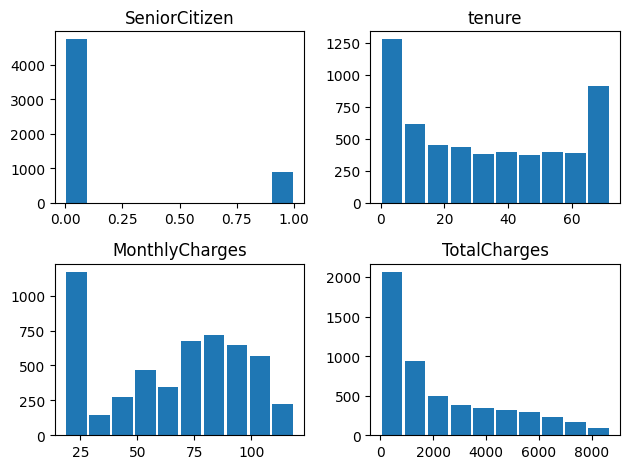

In [27]:
##Plot to understand numerical value distribution in training data

for i, col in enumerate(train_df_num_cols,1):
  plt.subplot(2,2,i)
  plt.hist(train_df[col],rwidth=0.9)
  plt.title(col)

plt.tight_layout()
plt.show()


1.   List item
2.   List item



In [28]:
##Handling Misiing values

train_data_median=train_df['TotalCharges'].median()

In [29]:
### Replacing missing values with median
train_df['TotalCharges'] =train_df['TotalCharges'].fillna(train_df['TotalCharges'].median())
train_df['MonthlyCharges'] = train_df['MonthlyCharges'].fillna(train_df['MonthlyCharges'].median())

In [30]:
# Replace the 2 NA values in test_df with the median
test_df['TotalCharges'] = test_df['TotalCharges'].fillna(test_df['TotalCharges'].median())


In [31]:
train_df.isna().sum()

,0
customerID,0
gender,169
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,169


In [32]:
train_df.isna().sum()

,0
customerID,0
gender,169
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,169


In [33]:
##Replacing categorical column null values with mode

train_df['gender'] = train_df['gender'].fillna(train_df['gender'].mode()[0])

train_df['OnlineSecurity'] = train_df['OnlineSecurity'].fillna(train_df['OnlineSecurity'].mode()[0])


In [34]:
train_df.isna().sum() ##After handlling null values

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [112]:
##Outlier handling
train_df.describe()

,gender,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No,...,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,CustomerLifetimeValue
count,5634.000000,5634.000000,5634.000000,5634.000000,5634.000000,5634.000000,5634.000000,5634.000000,5634.000000,5634.000000,...,5634.000000,5634.000000,5634.000000,5634.000000,5634.000000,5634.000000,5634.000000,5634.000000,5634.000000,5634.000000
mean,0.517039,0.487043,0.297125,0.452873,0.901846,0.594604,0.470050,0.256106,0.266951,0.479411,...,0.213525,0.390309,0.549166,0.208023,0.242812,0.221512,0.215832,0.335818,0.226837,0.235794
std,0.499754,0.499876,0.457032,0.341875,0.297549,0.491012,0.288764,0.255747,0.442406,0.499620,...,0.409832,0.487863,0.497621,0.405929,0.428820,0.415301,0.411435,0.472318,0.418824,0.260485
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.125000,1.000000,0.000000,0.256219,0.049298,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.016231
50%,1.000000,0.000000,0.000000,0.402778,1.000000,1.000000,0.521393,0.158967,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.123487
75%,1.000000,1.000000,1.000000,0.777778,1.000000,1.000000,0.704975,0.412152,1.000000,1.000000,...,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.401662
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


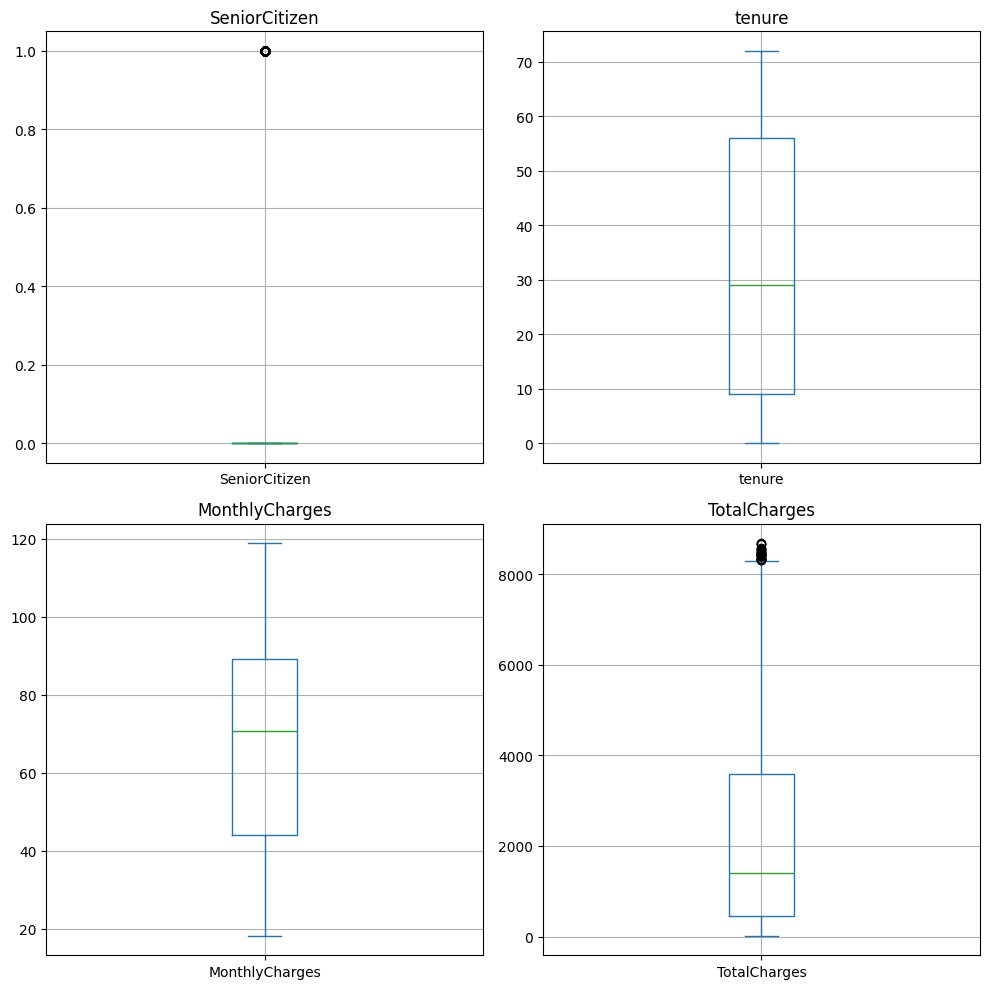

In [36]:
# ploting box plot to identify outlier

plt.figure(figsize=(10,10))
for i, col in enumerate (train_df_num_cols, 1):
  plt.subplot(2,2,i)
  train_df[col].plot(kind='box')
  plt.title(col)
  plt.grid()

plt.tight_layout()
plt.show()

In [37]:
Q1 = train_df[train_df_num_cols].quantile(0.25)
Q3 = train_df[train_df_num_cols].quantile(0.75)
IQR = Q3-Q1


upper_limit = Q3 + (1.5 * IQR)
lower_limit = Q1 - (1.5 * IQR)

outliers = ((train_df[train_df_num_cols] > upper_limit) | (train_df[train_df_num_cols] < lower_limit)).any(axis=1)

outliers_df = train_df[outliers]

outlier_percentage = len(outliers_df) * 100/ len(train_df)

print("percentage fo outliers in the dataframe :", outlier_percentage)

percentage fo outliers in the dataframe : 16.311679091231806


In [38]:
outliers_count = ((train_df[train_df_num_cols] > upper_limit) | (train_df[train_df_num_cols] < lower_limit)).mean()*100

In [39]:
outliers_count ## Outlier count is very less for both column

,0
SeniorCitizen,15.974441
tenure,0.000000
MonthlyCharges,0.000000
TotalCharges,0.425985


In [40]:
# Removing 'SeniorCitizen' from training data
train_df.drop(['SeniorCitizen'], axis=1, inplace=True)

In [41]:
# Removing 'SeniorCitizen' from testing data
test_df.drop(['SeniorCitizen'], axis=1, inplace=True)

In [42]:
# Update the numerical columns list to exclude the dropped 'SeniorCitizen'
train_df_num_cols = train_df.select_dtypes(include=['int64', 'float64']).columns

###Identifying coorelation

In [43]:
## Coorelation matrix of train data
corr_matrix = train_df[train_df_num_cols].corr(method='pearson')
corr_matrix

,tenure,MonthlyCharges,TotalCharges
tenure,1.000000,0.232216,0.796983
MonthlyCharges,0.232216,1.000000,0.606911
TotalCharges,0.796983,0.606911,1.000000


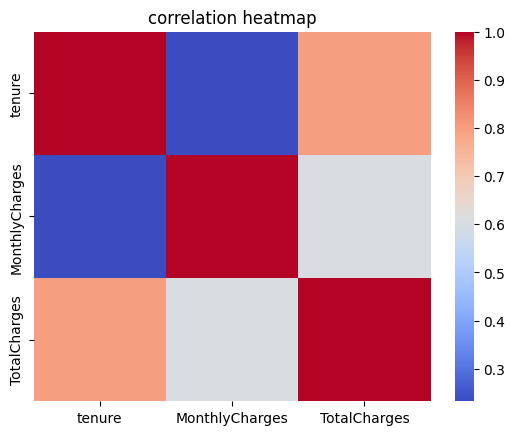

In [44]:
sns.heatmap(corr_matrix, cmap='coolwarm')
plt.title('correlation heatmap')
plt.show()

In [45]:
# removing column from training data
train_df.drop(['customerID'], axis=1, inplace=True) # removing customerID as it is an identifier not a valid contributor
train_df.head()

,gender,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,No,No,35,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.75,700.45,No
1,Female,No,No,28,No,No phone service,DSL,No,No,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,35.75,961.40,No
2,Male,No,No,56,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,No,Electronic check,98.60,5581.05,No
3,Male,Yes,No,39,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),20.45,790.00,No
4,Female,Yes,Yes,43,No,No phone service,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Bank transfer (automatic),51.25,2151.60,No


In [46]:
# removing column from testing data
test_df.drop(['customerID'], axis=1, inplace=True)
test_df.head(2)

,gender,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Male,Yes,Yes,40,Yes,Yes,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,81.20,3292.30,No
1,Female,Yes,No,12,Yes,Yes,DSL,Yes,No,Yes,No,Yes,Yes,One year,No,Electronic check,78.85,876.75,No


###Data tranformation

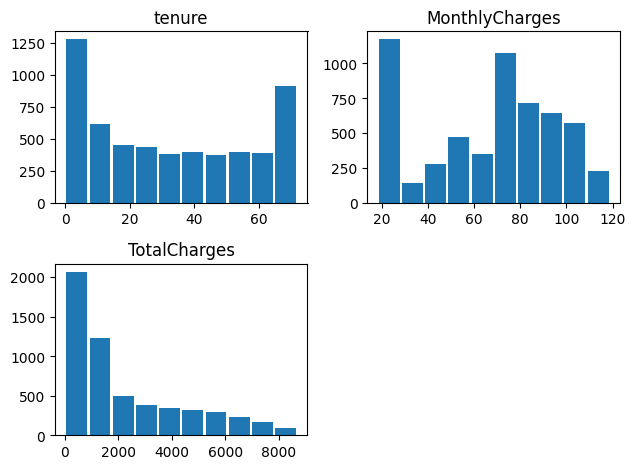

In [47]:
for i, col in enumerate(train_df_num_cols,1):
  plt.subplot(2,2,i)
  plt.hist(train_df[col],rwidth=0.9)
  plt.title(col)

plt.tight_layout()
plt.show()

In [48]:
train_df.describe() ##Before Scaling

,tenure,MonthlyCharges,TotalCharges
count,5634.000000,5634.000000,5634.000000
mean,32.606851,65.490034,2238.250728
std,24.614976,29.020760,2216.294428
min,0.000000,18.250000,18.850000
25%,9.000000,44.000000,446.062500
50%,29.000000,70.650000,1396.450000
75%,56.000000,89.100000,3590.537500
max,72.000000,118.750000,8684.800000


In [49]:
test_df.describe() ##Before scaling

,tenure,MonthlyCharges,TotalCharges
count,1409.000000,1409.000000,1409.000000
mean,31.428673,63.898013,2214.195848
std,24.322161,30.282693,2242.072790
min,0.000000,18.700000,18.800000
25%,8.000000,30.100000,360.100000
50%,27.000000,69.900000,1348.950000
75%,54.000000,89.500000,3673.600000
max,72.000000,118.600000,8547.150000


In [50]:
# scaling training data

min_max_scaler = MinMaxScaler() # using min- max scaler because the distribution is skewed
train_df[['tenure','MonthlyCharges','TotalCharges']] = min_max_scaler.fit_transform(train_df[['tenure','MonthlyCharges','TotalCharges']])
# senior ciitizen column is not skewed as it have binary values

In [51]:
# scaling testing data

min_max_scaler = MinMaxScaler() # using min- max scaler because the distribution is skewed
test_df[['tenure','MonthlyCharges','TotalCharges']] = min_max_scaler.fit_transform(test_df[['tenure','MonthlyCharges','TotalCharges']])


In [52]:
train_df.describe() ##After scaling

,tenure,MonthlyCharges,TotalCharges
count,5634.000000,5634.000000,5634.000000
mean,0.452873,0.470050,0.256106
std,0.341875,0.288764,0.255747
min,0.000000,0.000000,0.000000
25%,0.125000,0.256219,0.049298
50%,0.402778,0.521393,0.158967
75%,0.777778,0.704975,0.412152
max,1.000000,1.000000,1.000000


In [53]:
test_df.describe()

,tenure,MonthlyCharges,TotalCharges
count,1409.000000,1409.000000,1409.000000
mean,0.436509,0.452433,0.257423
std,0.337808,0.303130,0.262896
min,0.000000,0.000000,0.000000
25%,0.111111,0.114114,0.040019
50%,0.375000,0.512513,0.155968
75%,0.750000,0.708709,0.428547
max,1.000000,1.000000,1.000000


In [54]:
# corelation after scaling
corr_matrix = train_df[train_df_num_cols].corr(method='pearson')
corr_matrix

,tenure,MonthlyCharges,TotalCharges
tenure,1.000000,0.232216,0.796983
MonthlyCharges,0.232216,1.000000,0.606911
TotalCharges,0.796983,0.606911,1.000000


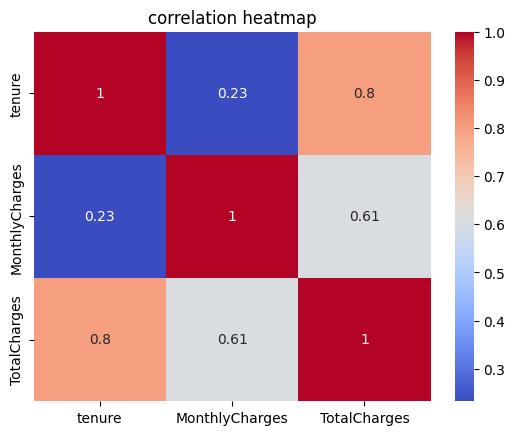

In [55]:
# ploting a heat map to visualize correlation after scaling
sns.heatmap(corr_matrix,annot=True, cmap='coolwarm')
plt.title('correlation heatmap')
plt.show()

In [56]:
## ENCODING

train_df.head() ##Before encoding

,gender,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,No,No,0.486111,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,0.024876,0.078653,No
1,Female,No,No,0.388889,No,No phone service,DSL,No,No,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,0.174129,0.108765,No
2,Male,No,No,0.777778,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,No,Electronic check,0.799502,0.641845,No
3,Male,Yes,No,0.541667,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),0.021891,0.088986,No
4,Female,Yes,Yes,0.597222,No,No phone service,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Bank transfer (automatic),0.328358,0.246107,No


In [57]:
train_df['Contract'].unique()

array(['One year', 'Month-to-month', 'Two year'], dtype=object)

In [58]:
train_df['DeviceProtection'].unique()

array(['No internet service', 'Yes', 'No'], dtype=object)

In [59]:
train_df['Partner'].unique()

array(['No', 'Yes'], dtype=object)

In [60]:
train_df['gender'].unique()

array(['Female', 'Male'], dtype=object)

In [61]:
train_df['Dependents'].unique()

array(['No', 'Yes'], dtype=object)

In [62]:
train_df['PhoneService'].unique()

array(['Yes', 'No'], dtype=object)

In [63]:
train_df['MultipleLines'].unique()

array(['No', 'No phone service', 'Yes'], dtype=object)

In [64]:
train_df['InternetService'].unique()

array(['No', 'DSL', 'Fiber optic'], dtype=object)

In [65]:
train_df['OnlineSecurity'].unique()

array(['No internet service', 'No', 'Yes'], dtype=object)

In [66]:
train_df['OnlineBackup'].unique()

array(['No internet service', 'No', 'Yes'], dtype=object)

In [67]:
train_df['TechSupport'].unique()

array(['No internet service', 'Yes', 'No'], dtype=object)

In [68]:
train_df['StreamingTV'].unique()

array(['No internet service', 'No', 'Yes'], dtype=object)

In [69]:
train_df['StreamingMovies'].unique()

array(['No internet service', 'No', 'Yes'], dtype=object)

In [70]:
train_df['PaperlessBilling'].unique()

array(['No', 'Yes'], dtype=object)

In [71]:
train_df['PaymentMethod'].unique()

array(['Mailed check', 'Electronic check', 'Bank transfer (automatic)',
       'Credit card (automatic)'], dtype=object)

In [72]:
# churn is the target therefore label encoder
# binary data - PaperlessBilling, Partner, gender, Dependents, PhoneService -- label encoding
# one hot encoding - MultipleLines, InternetService	, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, Contract, PaymentMethod

In [73]:
label_encoder = LabelEncoder()

train_df['Churn'] = label_encoder.fit_transform(train_df['Churn'])
train_df['PaperlessBilling'] = label_encoder.fit_transform(train_df['PaperlessBilling'])
train_df['Partner'] = label_encoder.fit_transform(train_df['Partner'])
train_df['gender'] = label_encoder.fit_transform(train_df['gender'])
train_df['Dependents'] = label_encoder.fit_transform(train_df['Dependents'])
train_df['PhoneService'] = label_encoder.fit_transform(train_df['PhoneService'])

In [74]:
# applying one hot encoding in above mentioned columns in training data

train_df = pd.get_dummies(train_df, columns=['MultipleLines','InternetService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','Contract','PaymentMethod'], dtype=int)

In [75]:
train_df.head()

,gender,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No,...,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,0,0.486111,1,0,0.024876,0.078653,0,1,...,0,1,0,0,1,0,0,0,0,1
1,0,0,0,0.388889,0,1,0.174129,0.108765,0,0,...,1,0,0,1,0,0,0,0,0,1
2,1,0,0,0.777778,1,0,0.799502,0.641845,0,0,...,0,0,1,1,0,0,0,0,1,0
3,1,1,0,0.541667,1,1,0.021891,0.088986,0,1,...,0,1,0,0,0,1,1,0,0,0
4,0,1,1,0.597222,0,1,0.328358,0.246107,0,0,...,1,0,0,0,1,0,1,0,0,0


In [76]:
##Label encoding tsting data

label_encoder = LabelEncoder()

test_df['Churn'] = label_encoder.fit_transform(test_df['Churn'])
test_df['PaperlessBilling'] = label_encoder.fit_transform(test_df['PaperlessBilling'])
test_df['Partner'] = label_encoder.fit_transform(test_df['Partner'])
test_df['gender'] = label_encoder.fit_transform(test_df['gender'])
test_df['Dependents'] = label_encoder.fit_transform(test_df['Dependents'])
test_df['PhoneService'] = label_encoder.fit_transform(test_df['PhoneService'])

In [77]:
# applying one hot encoding in above mentioned columns in training data

test_df = pd.get_dummies(test_df, columns=['MultipleLines','InternetService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','Contract','PaymentMethod'], dtype=int)

In [78]:
test_df.head() ##Testong after encoding

,gender,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No,...,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,1,1,0.555556,1,1,0.625626,0.383837,0,0,...,1,0,0,1,0,0,0,0,1,0
1,0,1,0,0.166667,1,0,0.602102,0.100600,0,0,...,0,0,1,0,1,0,0,0,1,0
2,1,0,0,0.597222,1,1,0.813814,0.491625,1,0,...,0,0,1,0,1,0,0,0,1,0
3,1,0,0,1.000000,1,1,0.995996,1.000000,0,0,...,0,0,1,0,0,1,0,0,1,0
4,0,0,0,0.138889,0,0,0.175676,0.041649,0,0,...,1,0,0,1,0,0,0,0,1,0


##Feature Engineering

In [79]:
# This estimates how much revenue a customer has generated.

train_df['CustomerLifetimeValue'] = (

    train_df['tenure'] *
    train_df['MonthlyCharges']
)

test_df['CustomerLifetimeValue'] = (
    test_df['tenure'] *
    test_df['MonthlyCharges']
)

In [80]:
train_df.head() ##After adding new feature

,gender,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No,...,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,CustomerLifetimeValue
0,0,0,0,0.486111,1,0,0.024876,0.078653,0,1,...,1,0,0,1,0,0,0,0,1,0.012092
1,0,0,0,0.388889,0,1,0.174129,0.108765,0,0,...,0,0,1,0,0,0,0,0,1,0.067717
2,1,0,0,0.777778,1,0,0.799502,0.641845,0,0,...,0,1,1,0,0,0,0,1,0,0.621835
3,1,1,0,0.541667,1,1,0.021891,0.088986,0,1,...,1,0,0,0,1,1,0,0,0,0.011857
4,0,1,1,0.597222,0,1,0.328358,0.246107,0,0,...,0,0,0,1,0,1,0,0,0,0.196103


In [81]:
test_df.head()  ##After adding new feature (test data)

,gender,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No,...,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,CustomerLifetimeValue
0,1,1,1,0.555556,1,1,0.625626,0.383837,0,0,...,0,0,1,0,0,0,0,1,0,0.347570
1,0,1,0,0.166667,1,0,0.602102,0.100600,0,0,...,0,1,0,1,0,0,0,1,0,0.100350
2,1,0,0,0.597222,1,1,0.813814,0.491625,1,0,...,0,1,0,1,0,0,0,1,0,0.486028
3,1,0,0,1.000000,1,1,0.995996,1.000000,0,0,...,0,1,0,0,1,0,0,1,0,0.995996
4,0,0,0,0.138889,0,0,0.175676,0.041649,0,0,...,0,0,1,0,0,0,0,1,0,0.024399


In [82]:
## Split Train data and test Data
X_train= train_df.drop('Churn', axis=1)


In [83]:
y_train= train_df['Churn']

In [84]:
X_test = test_df.drop('Churn', axis=1)


In [85]:
y_test= test_df['Churn']

##ML Model Building

In [86]:
## Logistic Regression

# 1. Get the columns from X_train
model_columns = X_train.columns

# 2. Reindex X_test to match X_train
X_test = X_test.reindex(columns=model_columns, fill_value=0)

#Initializing model
logreg_model= LogisticRegression()

##Trainig the model
logreg_model.fit(X_train,y_train)

##Prediction using trained model
y_pred_logistic_reg= logreg_model.predict(X_test)




In [87]:
# Model evaluavation

logreg_accuracy = accuracy_score(y_test, y_pred_logistic_reg)
logreg_conf_matrix = confusion_matrix(y_test, y_pred_logistic_reg)
log_reg_precision = precision_score(y_test, y_pred_logistic_reg)
log_reg_recall = recall_score(y_test, y_pred_logistic_reg)
log_reg_f1score = f1_score(y_test, y_pred_logistic_reg)


print(f"Accuracy is: {logreg_accuracy}")
print(f"confusion matrix is :{logreg_conf_matrix}")
print(f" Precision score is:{log_reg_precision}")
print(f" Recall score is:{log_reg_recall}")
print(f" f1 score is:{log_reg_f1score}")

Accuracy is: 0.8126330731014905
confusion matrix is :[[937 107]
 [157 208]]
 Precision score is:0.6603174603174603
 Recall score is:0.5698630136986301
 f1 score is:0.611764705882353


In [88]:
# KNN model

knn_model = KNeighborsClassifier(n_neighbors=3)
knn_model.fit(X_train,y_train)
y_pred_knn = knn_model.predict(X_test)

In [89]:
# KNN evaluvation
knn_accuracy = accuracy_score(y_test, y_pred_knn)
knn_conf_matrix = confusion_matrix(y_test, y_pred_knn)
knn_precision = precision_score(y_test, y_pred_knn)
knn_recall = recall_score(y_test, y_pred_knn)
knn_f1score = f1_score(y_test, y_pred_knn)


print(f"Accuracy of knn is: {knn_accuracy}")
print(f"confusion matrix is :{knn_conf_matrix}")
print(f" Precision score is:{knn_precision}")
print(f" Recall score is:{knn_recall}")
print(f" f1 score is:{knn_f1score}")

Accuracy of knn is: 0.7565649396735273
confusion matrix is :[[885 159]
 [184 181]]
 Precision score is:0.5323529411764706
 Recall score is:0.4958904109589041
 f1 score is:0.5134751773049645


In [90]:
# Naive bayes model

naive_bayes_model = GaussianNB()
naive_bayes_model.fit(X_train,y_train)
y_pred_naivebs = naive_bayes_model.predict(X_test)

In [91]:
nb_accuracy = accuracy_score(y_test, y_pred_naivebs)
nb_conf_matrix = confusion_matrix(y_test, y_pred_naivebs)
nb_precision = precision_score(y_test, y_pred_naivebs)
nb_recall = recall_score(y_test, y_pred_naivebs)
nb_f1score = f1_score(y_test, y_pred_naivebs)


print(f"Accuracy of naive bayes is: {nb_accuracy}")
print(f"confusion matrix is :{nb_conf_matrix}")
print(f" Precision score is:{nb_precision}")
print(f" Recall score is:{nb_recall}")
print(f" f1 score is:{nb_f1score}")

Accuracy of naive bayes is: 0.6820440028388929
confusion matrix is :[[664 380]
 [ 68 297]]
 Precision score is:0.43870014771048743
 Recall score is:0.8136986301369863
 f1 score is:0.5700575815738963


In [92]:
#SVM Model

svm_model = svm.SVC()
svm_model.fit(X_train,y_train)
y_pred_svm = svm_model.predict(X_test)

In [93]:
svm_accuracy = accuracy_score(y_test,y_pred_svm )
svm_conf_matrix = confusion_matrix(y_test, y_pred_svm)
svm_precision = precision_score(y_test, y_pred_svm)
svm_recall = recall_score(y_test, y_pred_svm)
svm_f1score = f1_score(y_test, y_pred_svm)


print(f"Accuracy of SVM is: {svm_accuracy}")
print(f"confusion matrix is :{svm_conf_matrix}")
print(f" Precision score is:{svm_precision}")
print(f" Recall score is:{svm_recall}")
print(f" f1 score is:{svm_f1score}")


Accuracy of SVM is: 0.8069552874378992
confusion matrix is :[[956  88]
 [184 181]]
 Precision score is:0.6728624535315985
 Recall score is:0.4958904109589041
 f1 score is:0.5709779179810726


In [94]:
# Decision Tree
desicion_tree_model = tree.DecisionTreeClassifier()
desicion_tree_model.fit(X_train,y_train)
y_pred_dtree = desicion_tree_model.predict(X_test)

In [95]:
dt_accuracy = accuracy_score(y_test,y_pred_dtree )
dt_conf_matrix = confusion_matrix(y_test, y_pred_dtree)
dt_precision = precision_score(y_test, y_pred_dtree)
dt_recall = recall_score(y_test, y_pred_dtree)
dt_f1score = f1_score(y_test, y_pred_dtree)


print(f"Accuracy of Decision Tree is: {dt_accuracy}")
print(f"confusion matrix is :{dt_conf_matrix}")
print(f" Precision score is:{dt_precision}")
print(f" Recall score is:{dt_recall}")
print(f" F1 score is:{dt_f1score}")

Accuracy of Decision Tree is: 0.7452093683463449
confusion matrix is :[[853 191]
 [168 197]]
 Precision score is:0.5077319587628866
 Recall score is:0.5397260273972603
 F1 score is:0.5232403718459495


In [98]:
 ## Evaluvation comparison before hyperparameter tuning

result_df = pd.DataFrame()
result_df['Model'] = ['Logistic Regression','KNN','Naive bayes','SVM','Decision Tree']
result_df['Accuracy'] = [logreg_accuracy,knn_accuracy,nb_accuracy,svm_accuracy,dt_accuracy]
result_df['Precision'] = [log_reg_precision,knn_precision,nb_precision,svm_precision,dt_precision]
result_df['Recall'] = [log_reg_recall,knn_recall,nb_recall,svm_recall,dt_recall]
result_df['f1 sccore'] = [log_reg_f1score,knn_f1score,nb_f1score,svm_f1score,dt_recall]



In [99]:
result_df

,Model,Accuracy,Precision,Recall,f1 sccore
0,Logistic Regression,0.812633,0.660317,0.569863,0.611765
1,KNN,0.756565,0.532353,0.495890,0.513475
2,Naive bayes,0.682044,0.438700,0.813699,0.570058
3,SVM,0.806955,0.672862,0.495890,0.570978
4,Decision Tree,0.745209,0.507732,0.539726,0.539726


##Model Fine Tuning

In [100]:
# Using GridSearchCV to fine tune the model
log_params = {
    'C': [0.01, 0.1, 1, 0.5],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'],
    'class_weight': [None, 'balanced']
}

log_grid = GridSearchCV(
    LogisticRegression(),
    param_grid=log_params,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

log_grid.fit(X_train, y_train)

print("Best Parameters:", log_grid.best_params_)
print("Best F1 Score:", log_grid.best_score_)

tuned_log_model = log_grid.best_estimator_

Best Parameters: {'C': 1, 'class_weight': 'balanced', 'penalty': 'l1', 'solver': 'liblinear'}
Best F1 Score: 0.6327213959934065


In [101]:
# prediction using fine tuned model
y_pred_log_tuned = tuned_log_model.predict(X_test)

In [102]:
logreg_accuracy_tuned = accuracy_score(y_test, y_pred_log_tuned)
logreg_conf_matrix_tuned = confusion_matrix(y_test, y_pred_log_tuned)
log_reg_precision_tuned = precision_score(y_test, y_pred_log_tuned)
log_reg_recall_tuned = recall_score(y_test, y_pred_log_tuned)
log_reg_f1score_tuned = f1_score(y_test, y_pred_log_tuned)

print(f"Accuracy is: {logreg_accuracy_tuned}")
print(f"confusion matrix is :{logreg_conf_matrix_tuned}")
print(f" Precision score is:{log_reg_precision_tuned}")
print(f" Recall score is:{log_reg_recall_tuned}")
print(f" f1 score is:{log_reg_f1score_tuned}")

Accuracy is: 0.7324343506032647
confusion matrix is :[[748 296]
 [ 81 284]]
 Precision score is:0.4896551724137931
 Recall score is:0.7780821917808219
 f1 score is:0.6010582010582011


In [105]:
# Using GridSearchCV to fine tune the model
knn_params = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid=knn_params,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

knn_grid.fit(X_train, y_train)

print("Best Parameters:", knn_grid.best_params_)
print("Best F1 Score:", knn_grid.best_score_)

fine_tuned_knn_model = knn_grid.best_estimator_

Best Parameters: {'metric': 'manhattan', 'n_neighbors': 15, 'weights': 'uniform'}
Best F1 Score: 0.5730697313916527


In [106]:
y_pred_knn_fine_tuned = fine_tuned_knn_model.predict(X_test)

In [107]:
knn_accuracy_tuned = accuracy_score(y_test, y_pred_knn_fine_tuned)
knn_conf_matrix_tuned = confusion_matrix(y_test, y_pred_knn_fine_tuned)
knn_precision_tuned = precision_score(y_test, y_pred_knn_fine_tuned)
knn_recall_tuned = recall_score(y_test, y_pred_knn_fine_tuned)
knn_f1score_tuned = f1_score(y_test, y_pred_knn_fine_tuned)

print(f"Accuracy of knn is: {knn_accuracy_tuned}")
print(f"confusion matrix is :{knn_conf_matrix_tuned}")
print(f" Precision score is:{knn_precision_tuned}")
print(f" Recall score is:{knn_recall_tuned}")
print(f" f1 score is:{knn_f1score_tuned}")

Accuracy of knn is: 0.7764371894960965
confusion matrix is :[[884 160]
 [155 210]]
 Precision score is:0.5675675675675675
 Recall score is:0.5753424657534246
 f1 score is:0.5714285714285714


In [108]:
# Using GridSearchCV to fine tune the model

svm_params = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto'],
    'class_weight': [None, 'balanced']
}

svm_grid = GridSearchCV(
    svm.SVC(),
    param_grid=svm_params,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

svm_grid.fit(X_train, y_train)

print("Best Parameters:", svm_grid.best_params_)
print("Best F1 Score:", svm_grid.best_score_)

fine_tuned_svm_model = svm_grid.best_estimator_

Best Parameters: {'C': 1, 'class_weight': 'balanced', 'gamma': 'scale', 'kernel': 'rbf'}
Best F1 Score: 0.6274876731562419


In [109]:
y_pred_svm_fine_tuned = fine_tuned_svm_model.predict(X_test)

In [110]:
svm_accuracy_tuned = accuracy_score(y_test,y_pred_svm_fine_tuned )
svm_conf_matrix_tuned = confusion_matrix(y_test, y_pred_svm_fine_tuned)
svm_precision_tuned = precision_score(y_test, y_pred_svm_fine_tuned)
svm_recall_tuned = recall_score(y_test, y_pred_svm_fine_tuned)
svm_f1score_tuned = f1_score(y_test, y_pred_svm_fine_tuned)

print(f"Accuracy of SVM is: {svm_accuracy_tuned}")
print(f"confusion matrix is :{svm_conf_matrix_tuned}")
print(f" Precision score is:{svm_precision_tuned}")
print(f" Recall score is:{svm_recall_tuned}")
print(f" f1 score is:{svm_f1score_tuned}")

Accuracy of SVM is: 0.7210787792760823
confusion matrix is :[[745 299]
 [ 94 271]]
 Precision score is:0.47543859649122805
 Recall score is:0.7424657534246575
 f1 score is:0.5796791443850268


In [111]:
# Using GridSearchCV to fine tune the model
dt_params = {
    'max_depth': [3, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

dt_grid = GridSearchCV(
    tree.DecisionTreeClassifier(random_state=42),
    param_grid=dt_params,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

dt_grid.fit(X_train, y_train)

print("Best Parameters:", dt_grid.best_params_)
print("Best F1 Score:", dt_grid.best_score_)

fine_tuned_dt_model = dt_grid.best_estimator_

Best Parameters: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2}
Best F1 Score: 0.5823609828174818


In [113]:
y_pred_dt_fine_tuned = fine_tuned_dt_model.predict(X_test)

In [114]:
dt_accuracy_tuned = accuracy_score(y_test,y_pred_dt_fine_tuned )
dt_conf_matrix_tuned = confusion_matrix(y_test, y_pred_dt_fine_tuned)
dt_precision_tuned = precision_score(y_test, y_pred_dt_fine_tuned)
dt_recall_tuned = recall_score(y_test, y_pred_dt_fine_tuned)
dt_f1score_tuned = f1_score(y_test, y_pred_dt_fine_tuned)

print(f"Accuracy of Decision Tree is: {dt_accuracy_tuned}")
print(f"confusion matrix is :{dt_conf_matrix_tuned}")
print(f" Precision score is:{dt_precision_tuned}")
print(f" Recall score is:{dt_recall_tuned}")
print(f" r1 score is:{dt_f1score_tuned}")

Accuracy of Decision Tree is: 0.7892122072391767
confusion matrix is :[[890 154]
 [143 222]]
 Precision score is:0.5904255319148937
 Recall score is:0.6082191780821918
 r1 score is:0.5991902834008097


In [115]:


results = [
    {
        'Model': 'Logistic Regression',
        'Accuracy': logreg_accuracy,
        'Precision': log_reg_precision,
        'Recall': log_reg_recall,
        'F1 Score': log_reg_f1score
    },

    {
        'Model': 'KNN',
        'Accuracy': knn_accuracy,
        'Precision': knn_precision,
        'Recall': knn_recall,
        'F1 Score': knn_f1score
    },

    {
        'Model': 'Naive Bayes',
        'Accuracy': nb_accuracy,
        'Precision': nb_precision,
        'Recall': nb_recall,
        'F1 Score': nb_f1score
    },

    {
        'Model': 'SVM',
        'Accuracy': svm_accuracy,
        'Precision': svm_precision,
        'Recall': svm_recall,
        'F1 Score': svm_f1score
    },

    {
        'Model': 'Decision Tree',
        'Accuracy': dt_accuracy,
        'Precision': dt_precision,
        'Recall': dt_recall,
        'F1 Score': dt_f1score
    },



    # Hypertuned Models
    {
        'Model': 'Logistic Regression Tuned',
        'Accuracy': logreg_accuracy_tuned,
        'Precision': log_reg_precision_tuned,
        'Recall': log_reg_recall_tuned,
        'F1 Score': log_reg_f1score_tuned
    },

    {
        'Model': 'KNN Tuned',
        'Accuracy': knn_accuracy_tuned,
        'Precision': knn_precision_tuned,
        'Recall': knn_recall_tuned,
        'F1 Score': knn_f1score_tuned
    },

    {
        'Model': 'SVM Tuned',
        'Accuracy': svm_accuracy_tuned,
        'Precision': svm_precision_tuned,
        'Recall': svm_recall_tuned,
        'F1 Score': svm_f1score_tuned
    },

    {
        'Model': 'Decision Tree Tuned',
        'Accuracy': dt_accuracy_tuned,
        'Precision': dt_precision_tuned,
        'Recall': dt_recall_tuned,
        'F1 Score': dt_f1score_tuned
    },

]

result_df = pd.DataFrame(results)

print(result_df)


                       Model  Accuracy  Precision    Recall  F1 Score
0        Logistic Regression  0.812633   0.660317  0.569863  0.611765
1                        KNN  0.756565   0.532353  0.495890  0.513475
2                Naive Bayes  0.682044   0.438700  0.813699  0.570058
3                        SVM  0.806955   0.672862  0.495890  0.570978
4              Decision Tree  0.745209   0.507732  0.539726  0.523240
5  Logistic Regression Tuned  0.732434   0.489655  0.778082  0.601058
6                  KNN Tuned  0.776437   0.567568  0.575342  0.571429
7                  SVM Tuned  0.721079   0.475439  0.742466  0.579679
8        Decision Tree Tuned  0.789212   0.590426  0.608219  0.599190


###Conclusion

######Here in churn prediction, recall is very important beacuase, loosing a customer who may churn is costly. According to performence metrics , we are getting the balanced model for Fine tuned Logistic Regression with 73% Accuracy and 77% Recall